<h1 style="color:yellow;"> PRODUCT CATEGORY CLASSIFICATION </h1>

### Author: Veronika Bazić

The goal of this notebook is to build a model that can suggest a product category from the product title.

I want the final solution to be useful at the moment a product is entered, so I treat **Product Title** as the main input. The dataset contains several other columns, but values such as number of views or merchant rating are not necessarily known when a new listing is created.

I will first inspect and clean the data, then compare a few text-classification approaches and finally test the selected model on the sample products from the assignment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

pd.set_option("display.max_columns", None)

## 1. Load and inspect the data

I start by checking the shape, column names, missing values and category labels. This is useful here because small differences in category spelling would otherwise be treated as completely different classes.

In [2]:
df = pd.read_csv("products.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head())
display(df.isna().sum().to_frame("missing_values"))
print("\nCategory labels:")
display(df["Category Label"].value_counts(dropna=False))

Shape: (35311, 8)


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


,missing_values
product ID,0
Product Title,172
Merchant ID,0
Category Label,44
_Product Code,95
Number_of_Views,14
Merchant Rating,170
Listing Date,59



Category labels:


Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
NaN                   44
Name: count, dtype: int64

### What I noticed

The raw file has **35,311 rows**. There are missing values in several columns, including Product Title and Category Label.

The category list also contains three naming inconsistencies: `Mobile Phone`, `CPU`, and `fridge`. These are not new categories; they are alternate forms of `Mobile Phones`, `CPUs`, and `Fridges`, so I standardize them before modeling.

In [3]:
data = df.dropna(subset=["Product Title", "Category Label"]).copy()

data["Product Title"] = data["Product Title"].astype(str).str.strip().str.lower()
data["Category Label"] = data["Category Label"].astype(str).str.strip()

data["Category Label"] = data["Category Label"].replace({
    "Mobile Phone": "Mobile Phones",
    "CPU": "CPUs",
    "fridge": "Fridges"
})

data = data[(data["Product Title"] != "") & (data["Category Label"] != "")]

before_dedup = len(data)
data = data.drop_duplicates(subset=["Product Title", "Category Label"]).reset_index(drop=True)

print("Rows after cleaning:", len(data))
print("Exact duplicate title/category pairs removed:", before_dedup - len(data))
display(data["Category Label"].value_counts())

Rows after cleaning: 30826
Exact duplicate title/category pairs removed: 4270


Category Label
Fridge Freezers     4809
Mobile Phones       3662
Washing Machines    3403
TVs                 3275
Fridges             3190
CPUs                3043
Dishwashers         3042
Digital Cameras     2405
Microwaves          2094
Freezers            1903
Name: count, dtype: int64

I removed exact duplicate title/category pairs before splitting the data. If the same title appeared in both training and test data, the evaluation could look better simply because the model had already seen that exact example.

After this step, **30,826 rows** remain.

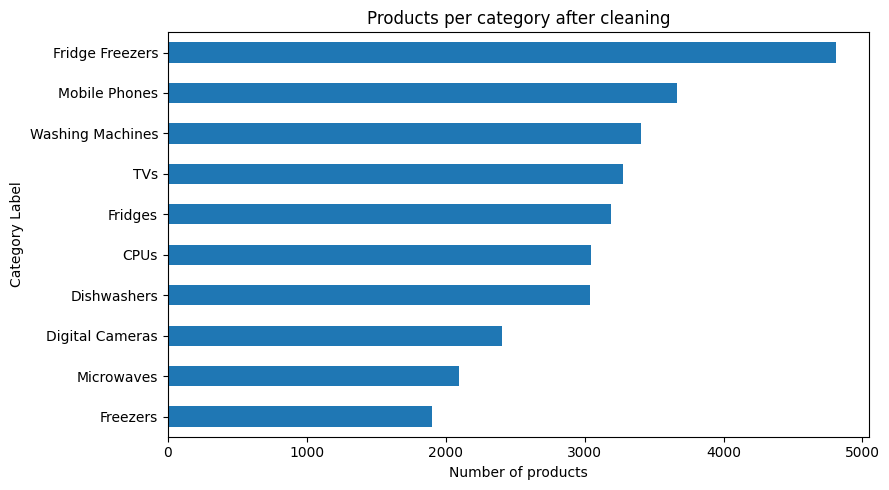

In [4]:
category_counts = data["Category Label"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
category_counts.plot(kind="barh")
plt.title("Products per category after cleaning")
plt.xlabel("Number of products")
plt.tight_layout()
plt.show()

## 2. Train-test split

I use a stratified 80/20 split so each category keeps approximately the same proportion in the training and test sets. The random state is fixed so the comparison is reproducible.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data["Product Title"],
    data["Category Label"],
    test_size=0.20,
    random_state=42,
    stratify=data["Category Label"]
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 24660
Test rows: 6166


## 3. Model experiments

I compare Logistic Regression and Linear SVC with word-level TF-IDF first. I also try Linear SVC with character n-grams.

The character approach is interesting for this dataset because product titles contain many model codes, storage sizes and abbreviations. A model can learn useful fragments of words and codes instead of depending only on complete words.

In [6]:
models = {
    "Logistic Regression (word TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, sublinear_tf=True
        )),
        ("model", LogisticRegression(max_iter=1500, random_state=42))
    ]),

    "Linear SVC (word TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, sublinear_tf=True
        )),
        ("model", LinearSVC(random_state=42))
    ]),

    "Linear SVC (character TF-IDF)": Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=120000
        )),
        ("model", LinearSVC(random_state=42))
    ])
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
display(results_df)

,Model,Accuracy,Macro F1,Weighted F1
2,Linear SVC (character TF-IDF),0.991729,0.991826,0.991727
1,Linear SVC (word TF-IDF),0.960266,0.962158,0.960300
0,Logistic Regression (word TF-IDF),0.951995,0.954333,0.952071


### Comparison

The results are quite clear:

- **Linear SVC with character TF-IDF:** accuracy **0.9917**, macro F1 **0.9918**
- **Linear SVC with word TF-IDF:** accuracy **0.9603**, macro F1 **0.9622**
- **Logistic Regression with word TF-IDF:** accuracy **0.9520**, macro F1 **0.9543**

The character-based Linear SVC is the strongest of the three. The difference is large enough that I would select it for the final pipeline rather than choosing only on simplicity.

In [7]:
best_name = "Linear SVC (character TF-IDF)"
best_model = models[best_name]
best_pred = predictions[best_name]

print(classification_report(y_test, best_pred, zero_division=0))

                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       609
 Digital Cameras       1.00      1.00      1.00       481
     Dishwashers       1.00      1.00      1.00       608
        Freezers       0.99      0.98      0.99       381
 Fridge Freezers       0.99      0.99      0.99       962
         Fridges       0.97      0.98      0.98       638
      Microwaves       1.00      0.99      0.99       419
   Mobile Phones       1.00      0.99      1.00       732
             TVs       1.00      1.00      1.00       655
Washing Machines       0.99      0.99      0.99       681

        accuracy                           0.99      6166
       macro avg       0.99      0.99      0.99      6166
    weighted avg       0.99      0.99      0.99      6166



## 4. Confusion matrix

Accuracy alone does not show which categories are being confused, so I also look at the confusion matrix for the selected model.

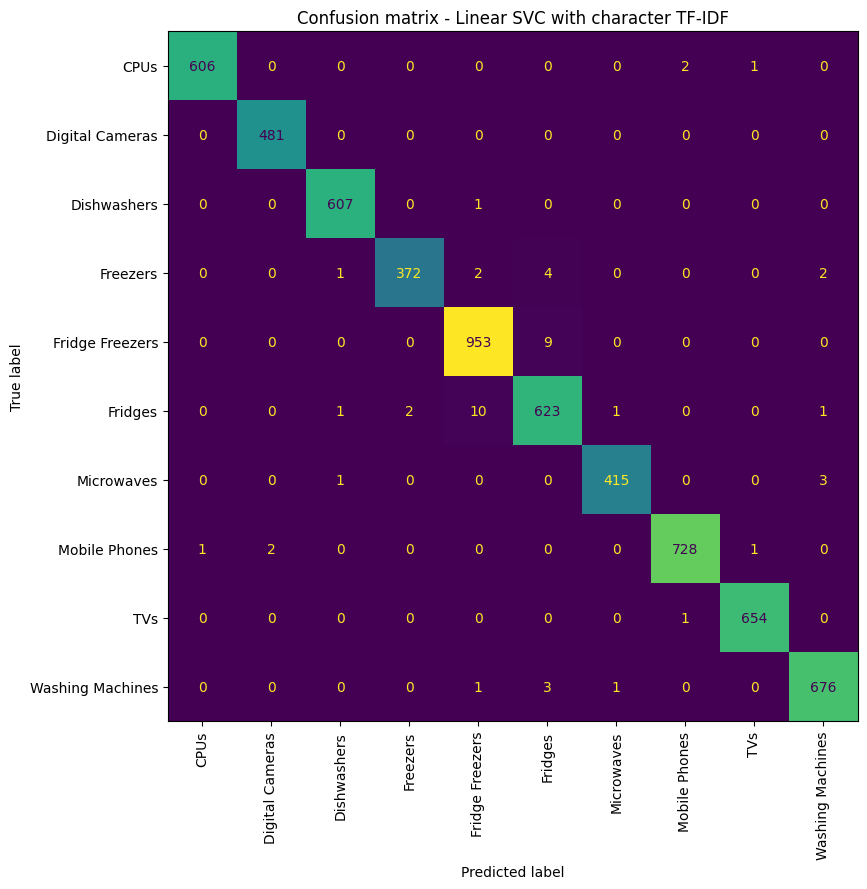

In [8]:
labels = sorted(data["Category Label"].unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion matrix - Linear SVC with character TF-IDF")
plt.tight_layout()
plt.show()

The matrix is strongly concentrated on the diagonal, which agrees with the high F1 score. The remaining mistakes are more useful to inspect than the overall accuracy because they show where future improvements should be focused.

## 5. Manual test with the products from the assignment

I now check the final approach on the six examples supplied with the task. These are useful because several of them contain short model codes rather than descriptive product names.

In [9]:
sample_products = [
    "iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",
    "olympus e m10 mark iii geh use silber",
    "kenwood k20mss15 solo",
    "bosch wap28390gb 8kg 1400 spin",
    "bosch serie 4 kgv39vl31g",
    "smeg sbs8004po"
]

expected = [
    "Mobile Phones",
    "Digital Cameras",
    "Microwaves",
    "Washing Machines",
    "Fridge Freezers",
    "Fridge Freezers"
]

# Refit the selected pipeline on all cleaned data before the final manual check.
best_model.fit(data["Product Title"], data["Category Label"])
sample_pred = best_model.predict(sample_products)

manual_test = pd.DataFrame({
    "Product Title": sample_products,
    "Expected": expected,
    "Predicted": sample_pred
})
manual_test["Match"] = manual_test["Expected"] == manual_test["Predicted"]

display(manual_test)

,Product Title,Expected,Predicted,Match
0,"iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",Mobile Phones,Mobile Phones,True
1,olympus e m10 mark iii geh use silber,Digital Cameras,Digital Cameras,True
2,kenwood k20mss15 solo,Microwaves,Microwaves,True
3,bosch wap28390gb 8kg 1400 spin,Washing Machines,Washing Machines,True
4,bosch serie 4 kgv39vl31g,Fridge Freezers,Fridge Freezers,True
5,smeg sbs8004po,Fridge Freezers,Fridge Freezers,True


All six supplied examples are classified as expected. I find the `smeg sbs8004po` and Bosch model-code examples especially useful here because they show why character n-grams are a good fit for product titles.

## 6. Final decision

I would use **Linear SVC with character-level TF-IDF** as the final model.

It reached about **99.17% accuracy** and **0.9918 macro F1** on the held-out test set, and it also predicted all six supplied test products correctly.

The main reason for choosing it is not only the final accuracy. Product titles often contain fragments such as model numbers, capacities and abbreviations, and the character representation handled this type of text noticeably better than the word-based alternatives.

For a real production system, I would still test the model on newer listings collected after the training period. A high score on the current dataset does not guarantee that future product names and new model ranges will behave in exactly the same way.